# Displacement controlled tests for out of plane weak layer fracture toughness 

**Valentin Adam**<sup>1,2</sup>, **Bastian Bergfeld**<sup>2</sup>, **Jakob Schöttner**<sup>2</sup>, **Melin Dominique Erin Walet**<sup>2</sup>, **Philipp Weißgraeber**<sup>3</sup>, **Alec van Herwijnen**<sup>2</sup> & **Philipp L. Rosendahl**<sup>1</sup>

<sup>1</sup>Center of Snow and Avalanche Mechanics, Technical University of Darmstadt, Germany.<br>
<sup>2</sup>Department, WSL Institute for Snow and Avalanche Research SLF, Davos, Switzerland.<br>
<sup>3</sup>Faculty of Mechanical Engineering and Marine Technology, University of Rostock, Germany.

---
## CONTENTS

1. [Preamble](#1.-preamble)<br>
2. [Data](#2.-data)<br>
2.1. [Data handling](#2.1.-data-handling)<br>
2.2. [Data structure](#2.2.-data-structure)<br>
2.3. [Import field data](#2.3.-import-field-data)<br>
2.4. [Import and preprocess loading data](#2.4.-import-and-preprocess-loading-data)<br>
3. [Analysis](#3.-analysis)<br>
3.1. [Load signal analysis](#3.1.-load-signal-analysis)<br>
3.2. [Fracture path](#3.2-fracture-path)<br>
4. [Digital Image Correlation](#4.-digital-image-correlation)<br>
4.1. [Camera calibration](#4.1-camera-calibration)<br>
4.2. [Geometry selection](#4.2-geometry-selection)<br>

---
## 1. PREAMBLE

In [52]:
%matplotlib widget

# Third-party imports
from IPython.display import display
import pandas as pd

# Project imports
import data_config as dc
import layout as lo
import visualisation as vis

# Better list display in pandas
pd.set_option('display.max_colwidth', 50)  # Allow longer column content
pd.set_option('display.max_columns', None)  # Show all columns  
pd.set_option('display.width', None)        # No width limit

# Predefine data paths
print(f"Server accessible: {dc.check_server_availability()}")
path_motor_unit_data =  dc.get_data_path('01_raw_data','02_motor_unit_data')
path_videos =  dc.get_data_path('01_raw_data','03_videos')
path_metadata =  dc.get_data_path('01_raw_data','04_metadata')

# Plot setup
%config InlineBackend.figure_formats = 'svg'
%matplotlib inline
%matplotlib widget

# Magic to reload modules
%load_ext autoreload
%autoreload 2

Using font: Minion Pro
Server accessible: True
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
# custom color palette
 
lo.print_color_palette()

Color Palette:
red          : #dc0100
orange       : #fa8200
gold         : #ffcd00
lightblue    : #000a51
blue         : #2588bf
indigo       : #75d3f2


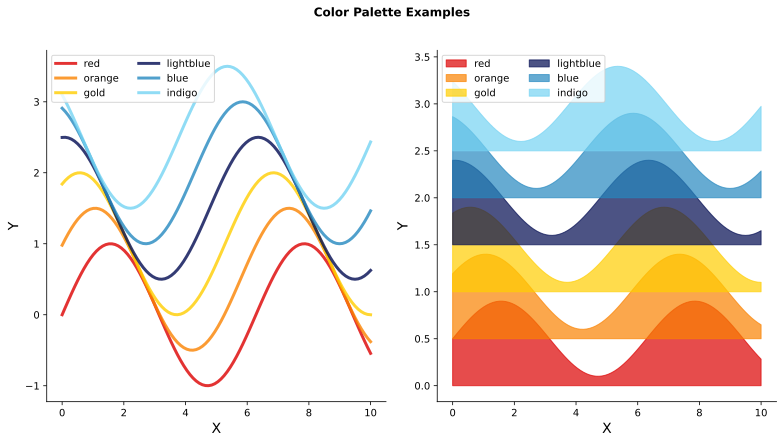

In [54]:
lo.plot_color_examples()

---
## 2. DATA

### 2.1. Data handling

Cross-platform server data access for team collaboration.

In [55]:
# Quick test
print(f"Platform: {dc.get_smb_info()['platform']}")
print(f"Server accessible: {dc.check_server_availability()}")
print(f"Server path: {dc.get_server_path()}")

Platform: Darwin
Server accessible: True
Server path: /Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled


In [56]:
#Predefining data paths:

# Raw data paths (01_raw_data folder)

print("Raw Data Paths (01_raw_data folder):")
print("=" * 40)
print("Motor unit data:")
print(f"• Path: {path_motor_unit_data}")
print("-" * 40)
print("Videos:")
print(f"• Path: {path_videos}")
print("-" * 40)
print("Metadata:")
print(f"• Path: {path_metadata}")



Raw Data Paths (01_raw_data folder):
Motor unit data:
• Path: /Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/02_motor_unit_data
----------------------------------------
Videos:
• Path: /Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/03_videos
----------------------------------------
Metadata:
• Path: /Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/04_metadata


### 2.2. Data structure 

This section describes the data structure used for the Mode3DC project, which is designed to be both internally organized for team collaboration and externally accessible for data sharing.

#### Data Organization Overview

This project uses a **master dataset approach** with two core Parquet files:

- **`M3DC_raw.parquet`** - Master data containing all experimental measurements
- **`M3DC_raw_info.parquet`** - Information describing each column (units, data types, descriptions)

**Key principles:**
- **Single source of truth**: All data updates go to the master files
- **Type preservation**: Parquet format maintains data types and handles complex structures (lists, tuples)
- **Information tracking**: Every column has corresponding information data for documentation
- **Incremental updates**: New data is merged into existing files rather than creating new ones
- **Analysis separation**: Analysis results are saved to separate files and merged back later

This approach ensures data consistency and traceability throughout the entire workflow.

#### Folder Structure

<div style="font-family: 'Courier New', monospace; background-color: #f8f9fa; padding: 20px; border-radius: 8px; border-left: 4px solid #007bff; margin: 20px 0;">

<strong style="color: #007bff;">2025_Mode_III_displacement_controlled/</strong><br>
├── <span style="color: #8319d7; font-weight: bold;">01_raw_data/</span>                    # Original, unmodified data<br>
│   ├── <span style="color: #6c757d;">01_fieldbooks</span>             
│   ├── <span style="color: #6c757d;">02_motor_unit_data</span><br>
│   ├── <span style="color: #6c757d;">03_videos</span>   # HFR videos 250 fps sony<br> 
│   └── <span style="color: #6c757d;">04_metadata</span> <br> 
│<br>
├── <span style="color: #c54325; font-weight: bold;">02_processed_data/</span>              # Intermediate processing results<br>
├── <span style="color: #51612c; font-weight: bold;">03_analysis_results/</span>            # Analysis outputs (future use)<br>
└── <span style="color: #ac2e85; font-weight: bold;">04_final_outputs/</span>               # Final figures and reports (future use)

</div>

The data is available through following download link: **link**

### 2.3. Import field data

This section imports experimental field data from Excel files into the master Parquet dataset.

**What happens:**
- **Input**: Excel file (`mode_III_dc.xlsx`) containing experimental metadata and measurements
- **Processing**: Data is parsed, type-converted, and validated according to predefined schemas
- **Output**: Two master Parquet files are created/updated:
  - `M3DC_raw.parquet` - Main experimental data
  - `M3DC_raw_info.parquet` - Column metadata (units, data types, descriptions)

**Key features:**
- **Type conversion**: Automatically converts Excel data types (datetime, time, integers, floats, booleans, strings)
- **Time handling**: Converts time formats (HH:MM:SS, mm:ss) to consistent float seconds
- **Force overwrite**: Option to update existing data or create new master files
- **Duplicate detection**: Prevents duplicate columns in both data and metadata
- **Metadata generation**: Creates comprehensive column descriptions for documentation

**Data structure check:**
- Verify that all expected columns are present in the data_export sheet 
- columns which should not be loaded in the master source can be excluded 
- In the data_export sheet the time columns needs to be excel time format 
- make shure to exclude the internal note row from data_export sheet
- Check data types match experimental requirements
- Ensure time data is properly converted to seconds
- Validate that AFN (Automated File Number) identifiers are unique

This step establishes the foundation of the master dataset that all subsequent analysis will build upon.

In [57]:
# Import experimental field data
M3DC_raw, M3DC_raw_info = dc.import_split_and_save_field_data_excel(
    path_metadata+"/mode_III_dc.xlsx", 
    data_type_conversion=True,
    sheet_name="data_export",
    save_as="M3DC_raw",
    force_overwrite=True,
    exclude_columns=['screenshot of the force path']
)

Importing: /Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/04_metadata/mode_III_dc.xlsx
Reading sheet: data_export
Applying data type conversion...
Converted 34 columns: AFN (integer), date (datetime), T_s1 (float), T_s2 (float), T_s3 (float), rho_1 (float), rho_2 (float), rho_3 (float), rho_4 (float), rho_sub (float), h_s1 (float), h_s2 (float), h_s (float), P_e (float), sf front (string), sf back (string), a (float), psi (float), L (float), weight number (integer), weights (integer), l_dw (float), field row (integer), note (string), quality (string), pixel per mm (float), camera (string), pixel convertation (float), rotation correction (float), shear speed (float), gearbox (integer), motor Unit (integer), motor speed (float), samples per mm (float)
Successfully imported:
  df_raw shape: (77, 35)
  df_raw_info shape: (35, 5)
  Last column in data: samples per mm
  Last abbreviation in metadata: samples per m

In [58]:
M3DC_raw = dc.import_parquet(path_metadata+"/M3DC_raw.parquet")
display(M3DC_raw)
M3DC_raw_info = dc.import_parquet(path_metadata+"/M3DC_raw_info.parquet")
display(M3DC_raw_info)

Successfully imported Parquet: /Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/04_metadata/M3DC_raw.parquet
Shape: (77, 37)
Columns: ['AFN', 'date', 'T_s1', 'T_s2', 'T_s3', 'rho_1', 'rho_2', 'rho_3', 'rho_4', 'rho_sub', 'h_s1', 'h_s2', 'h_s', 'P_e', 'sf front', 'sf back', 'a', 'psi', 'L', 'weight number', 'weights', 'l_dw', 'field row', 'note', 'quality', 'pixel per mm', 'camera', 'field workers', 'pixel convertation', 'rotation correction', 'shear speed', 'gearbox', 'motor Unit', 'motor speed', 'samples per mm', 'w_data', 'P_data']


,AFN,date,T_s1,T_s2,T_s3,rho_1,rho_2,rho_3,rho_4,rho_sub,h_s1,h_s2,h_s,P_e,sf front,sf back,a,psi,L,weight number,weights,l_dw,field row,note,quality,pixel per mm,camera,field workers,pixel convertation,rotation correction,shear speed,gearbox,motor Unit,motor speed,samples per mm,w_data,P_data
0,176,2025-02-28,-5.5,-3.9,-3.5,137.0,142.0,141,158,NaN,110,110,110.0,111.0,315.0,315.0,100.0,25.5,NaN,<NA>,<NA>,NaN,1,None,None,NaN,None,Amelie Fees,NaN,NaN,2000.0,246,2,644.0,1341.0,"[0.0, 0.0007, 0.0015, 0.0022, 0.003, 0.0037, 0...","[3.8641, 3.8641, 3.8334, 3.8334, 3.8641, 3.864..."
1,177,2025-02-28,-8.0,-4.4,-3.8,135.0,145.0,147,156,NaN,115,115,115.0,112.0,225.0,285.0,150.0,25.0,NaN,<NA>,<NA>,NaN,<NA>,None,None,NaN,None,None,NaN,NaN,2000.0,246,2,644.0,1341.0,"[0.0, 0.0007, 0.0015, 0.0022, 0.003, 0.0037, 0...","[3.8947, 3.8947, 3.8641, 3.8947, 3.8947, 3.864..."
2,178,2025-02-28,-9.3,-6.2,-5.2,151.0,152.0,151,159,NaN,110,105,107.5,102.0,46.0,41.0,150.0,25.0,NaN,<NA>,<NA>,NaN,<NA>,None,None,NaN,None,None,NaN,NaN,2000.0,246,2,644.0,1341.0,"[0.0, 0.0007, 0.0015, 0.0022, 0.003, 0.0037, 0...","[3.8641, 3.8947, 3.9254, 3.9254, 3.8641, 3.894..."
3,180,2025-02-28,-5.4,-4.0,-3.5,135.0,144.0,145,158,NaN,112,115,113.5,104.0,24.0,28.0,160.0,27.0,NaN,<NA>,<NA>,NaN,<NA>,uncertain if correct number,None,NaN,None,None,NaN,NaN,2000.0,246,2,644.0,1341.0,"[0.0, 0.0007, 0.0015, 0.0022, 0.003, 0.0037, 0...","[3.8947, 3.8641, 3.8947, 3.8641, 3.8641, 3.864..."
4,181,2025-02-28,-6.3,-5.4,-3.8,135.0,143.0,157,149,NaN,105,115,110.0,92.0,25.0,25.0,160.0,27.5,NaN,<NA>,<NA>,NaN,<NA>,"captured with casio 250 fps; 1,5mm in 1s linea...",None,NaN,casio 250 fps,None,NaN,NaN,2000.0,246,2,644.0,1341.0,"[0.0, 0.0007, 0.0015, 0.0022, 0.003, 0.0037, 0...","[3.8641, 3.8641, 3.8334, 3.8334, 3.8641, 3.833..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,<NA>,2025-03-12,-2.2,-2.8,-2.3,145.0,171.0,158,167,NaN,110,100,105.0,0.0,None,None,140.0,27.0,400.0,2,3,NaN,<NA>,None,None,NaN,None,None,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,None,None
73,<NA>,2025-03-12,-2.8,-2.9,-2.8,167.0,156.0,160,172,NaN,100,95,97.5,0.0,None,None,147.5,26.5,400.0,2,3,NaN,<NA>,without white cap,None,NaN,None,None,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,None,None
74,<NA>,2025-03-12,-2.4,-2.6,-3.0,164.0,155.0,162,166,NaN,90,90,90.0,0.0,None,None,150.0,26.0,400.0,2,3,NaN,<NA>,None,None,NaN,None,None,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,None,None
75,<NA>,2025-03-12,-2.5,-2.9,-2.8,167.0,152.0,167,172,NaN,105,105,105.0,0.0,None,None,145.0,27.2,400.0,2,3,NaN,<NA>,None,None,NaN,None,None,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,None,None


Successfully imported Parquet: /Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/04_metadata/M3DC_raw_info.parquet
Shape: (37, 5)
Columns: ['Abreviation', 'Units', 'Data_Type', 'Long Name', 'Description']


,Abreviation,Units,Data_Type,Long Name,Description
0,AFN,None,Integer,automated file number,Automated file number saved from motor untit a...
1,L,mm,Float,Length of the slab,Length of the slab. In those experiments where...
2,P_data,N,List,force,force signal of the load cell
3,P_e,N,Float,critical fracture Force estimate,The force was red directly from display in fie...
4,T_s1,◦C,Float,Slabs temperature at the top,Slabs temperature right after experiment 15 mm...
5,T_s2,◦C,Float,Slabs temperature at the bottom,Slabs temperature right after experiment 15 mm...
6,T_s3,◦C,Float,Substratum temperature,Temperature of the substratum 15 mm below weak...
7,a,mm,Float,pre cut/notch distance,Distance of precut inserted prior experiment t...
8,camera,None,String,Camera in use,The model of the camera which was used for fil...
9,date,None,Datetime: YYYY-MM-DD,date,date of the experiment


### 2.4. Import and preprocess loading data

This section merges load signal data from multiple CSV files into the master Parquet dataset.

**What happens:**
- **Input**: Multiple CSV files containing distance-force measurements (`MSCU{AFN}_samples.csv`)
- **Processing**: Load data is merged as list format into the master dataset
- **Output**: Updated master Parquet files with new columns:
  - `w_data` (distance) - List of distance measurements in mm
  - `P_data` (force) - List of force measurements in N

**Key features:**
- **List format storage**: Each AFN row contains complete time series as lists
- **Automatic detection**: Finds all load data files matching the pattern
- **Force overwrite**: Option to update existing load data or skip if already present
- **Metadata generation**: Creates column descriptions for distance and force measurements
- **Duplicate prevention**: Checks for existing columns before adding new ones

**Data structure check:**
- Verify that distance and force lists have matching lengths
- Check that all AFNs from master data have corresponding load files
- Ensure proper units (mm for distance, N for force)
- Validate that time series data is properly formatted as lists

**Integration**: This step adds the mechanical loading data that will be analyzed in the next section using the interactive load signal analyser.

In [ ]:
# Merge raw data with load data 
M3DC_raw_load,M3DC_raw_load_info = dc.merge_load_data(
    raw_data_path=path_metadata+"/M3DC_raw.parquet",
    raw_info_data_path=path_metadata+"/M3DC_raw_info.parquet", 
    load_data_dir=path_motor_unit_data,
    force_overwrite=False
)

Loaded master data from: /Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/04_metadata/M3DC_raw.parquet
Loaded master metadata from: /Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/04_metadata/M3DC_raw_info.parquet
Force overwrite enabled - updating existing load data columns: ['w_data', 'P_data']
Found loading data for AFN 176: 22378 measurements
Found loading data for AFN 177: 70225 measurements
Found loading data for AFN 178: 27273 measurements
Found loading data for AFN 180: 50008 measurements
Found loading data for AFN 181: 54422 measurements
Found loading data for AFN 182: 47370 measurements
Found loading data for AFN 183: 35202 measurements
Found loading data for AFN 188: 89693 measurements
Found loading data for AFN 191: 62933 measurements
Found loading data for AFN 192: 74972 measurements
Found loading data for AFN 193: 51135

In [ ]:
vis.distance_force_plot(path_metadata+"/M3DC_raw.parquet", title="M3DC distance vs load")

Loaded data from Parquet: /Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/04_metadata/M3DC_raw.parquet


Output()

## 3. Analysis

### 3.1. Load signal analysis

This section performs interactive manual analysis of load-distance curves from load cell to extract key mechanical properties.

**What happens:**
- **Interactive analysis**: Uses `load_signal_analyser.py` for manual point selection on load-distance plots
- **Three analysis modes**:
  - **Offset region (O)**: Select baseline region to calculate load cell offset (`P_off`)
  - **Linear region (L)**: Select linear portion to calculate global stiffness (`k`)
  - **Peak selection (P)**: Select critical fracture force (`P_c`)
- **Data storage**: Analysis results saved to `{prefix}_load_signal_analysis.parquet`
- **Integration**: Results merged back into master dataset using `merge_load_analyser_data()`

**Key features:**
- **Interactive plotting**: Click-to-select interface with visual feedback
- **AFN navigation**: Browse through all specimens using arrow keys
- **Drawing mode toggle**: Switch between analysis and zoom modes
- **Real-time calculation**: Immediate feedback on selected values
- **Automatic saving**: Each completed analysis is saved immediately

**Analysis outputs:**
- `offset_region`: [x_start, x_end] coordinates of baseline region
- `P_off`: Average force in offset region (N)
- `start_lin`: (x,y) coordinates of linear region start
- `end_lin`: (x,y) coordinates of linear region end  
- `k`: Global stiffness (N/mm) calculated from linear region slope
- `P_c`: (x,y) coordinates of critical fracture force

**Data structure check:**
- Verify that all specimens have been analyzed
- Check that calculated stiffness values are physically reasonable
- Ensure peak forces are properly identified
- Validate that offset regions are correctly selected

**Workflow**: Run the analyser for all specimens, then merge results back into the master dataset for further analysis.

In [61]:
# print path to parquet file
print(path_metadata + "/M3DC_raw.parquet")

/Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/04_metadata/M3DC_raw.parquet


**Copy following line for usage of load signal analyser in your terminal:**</br>
python load_signal_analyser.py "/Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/04_metadata/M3DC_raw.parquet"


In [ ]:
# After running load signal analyser (saves M3DC_load_signal_analysis.parquet to masters and info parquet)
df, df_info = dc.merge_load_analyser_data(
    raw_data_path=path_metadata + "/M3DC_raw.parquet",
    raw_info_data_path=path_metadata + "/M3DC_raw_info.parquet",
    force_overwrite=True
)

Loaded master data from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw.parquet
Loaded master metadata from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw_info.parquet
Loaded analysis data from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_load_signal_analysis.parquet
Force overwrite enabled - updating existing analysis columns: ['offset_region', 'P_off', 'start_lin', 'end_lin', 'k', 'P_c', 'F_dot']
Merged analysis data for AFN 1001
Merged analysis data for AFN 1003
Merged analysis data for AFN 1004
Merged analysis data for AFN 1005
Merged analysis data for AFN 1006
Merged analysis data for AFN 1007
Merged analysis data for AFN 1008
Merged analysis data for AFN 1009
Merged analysis data for AFN 1011
Merged analysis data for AFN 1013
Merged analysis data for AFN 1015
Merged analysis data for AFN 1018
Merged analysis data for AFN 1020
Merged an

In [ ]:
M3DC_raw = dc.import_parquet(path_metadata+"/M3DC_raw.parquet")
display(M3DC_raw.head(2))
M3DC_raw_info = dc.import_parquet(path_metadata+"/M3DC_raw_info.parquet")
display(M3DC_raw_info.tail(7))

Successfully imported Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw.parquet
Shape: (107, 42)
Columns: ['AFN', 'date', 'v', 'h', 'LOI', 'letterslot', 'notch percentage', 'combination', 'd', 'a', 'T', 'rho_1', 'rho_2', 'rho', 'preload', 'start preload', 'end preload', 'P_pre', 'quality of preload', 'exp start', 'exp end', 'peak number', 'P_e', 'quality', 'success', 'note', 'crack growth', 'gearbox', 'motor Unit', 'shear speed', 'motor speed', 'samples per mm', 'w', 'P', 'offset_region', 'P_off', 'start_lin', 'end_lin', 'k', 'P_c', 'pixel per mm', 'F_dot']


,AFN,date,v,h,LOI,letterslot,notch percentage,combination,d,a,T,rho_1,rho_2,rho,preload,start preload,end preload,P_pre,quality of preload,exp start,exp end,peak number,P_e,quality,success,note,crack growth,gearbox,motor Unit,shear speed,motor speed,samples per mm,w,P,offset_region,P_off,start_lin,end_lin,k,P_c,pixel per mm,F_dot
0,1001,2025-01-20,1650,125,U,A,1,A1,0.0,90.0,-6.6,337.0,336.0,336.5,0,None,None,NaN,2,00:37:00,00:42:00,0,71.930,0,True,REF,1,111,1,1650,240,1210,"[0.0, 0.0008, 0.0017, 0.0025, 0.0033, 0.0041, ...","[0.0, 2.5991, 2.5991, 2.5689, 2.5991, 2.6294, ...","[0.0314, 14.0306]",2.737738,"[15.5967, 55.7906]","[15.6595, 70.7809]",238.699045,"[15.6868, 71.9294]",NaN,393.853424
1,1003,2025-01-20,1650,125,U,A,1,A1,0.0,90.0,-6.7,301.0,302.0,301.5,0,None,None,NaN,2,00:14:00,00:19:00,0,62.803,0,True,None,1,111,1,1650,240,1210,"[0.0, 0.0008, 0.0017, 0.0025, 0.0033, 0.0041, ...","[3.8382, 3.8685, 3.8685, 3.8685, 3.8382, 3.868...","[0.0, 11.3]",3.823118,"[13.2397, 45.0617]","[13.3248, 61.5329]",193.551116,"[13.3413, 62.8022]",NaN,319.359342


Successfully imported Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw_info.parquet
Shape: (41, 5)
Columns: ['Abreviation', 'Units', 'Data_Type', 'Long Name', 'Description']


,Abreviation,Units,Data_Type,Long Name,Description
34,offset_region,mm,List,x region of offset calculation,the x region where the offset is calculated as...
35,P_off,N,Float,offset of the load cell,offset which was calculated on the signal duri...
36,start_lin,None,Coordinates as Tuple,start of linear signal before failure,starting point where the global stiffness is c...
37,end_lin,None,Coordinates as Tuple,end of the linear rise before failure,end of the linear rise before failure or plast...
38,k,N/mm,Float,global stiffness,global stiffness of the bending sample calcula...
39,P_c,N,Coordinates as Tuple,critical fracture Force,critical force at the time of the crack onset
40,F_dot,N/s,Float,global force rate,The global force rate quantifies how quickly t...
